# Seasonal Agriculture Performance Analysis
### VOIS AICTE Batch 1 2026–2027 — Major Project


## 1. Import libraries and load the dataset

In Google Colab, the first cell below opens an upload box. Upload the supplied agriculture CSV file.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


df = pd.read_csv('vios data set agriculture.csv')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Shape: 4000 rows x 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 2. Understand the dataset

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nUnique values:")
display(df.nunique().sort_values(ascending=False).to_frame("unique_values"))

print("\nBasic statistics:")
display(df.describe(include="all").T)

Rows: 4000
Columns: 28

Data types:


,dtype
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64



Unique values:


,unique_values
Farm_ID,4000
Total_Cost_INR,3995
Revenue_INR,3993
Profit_INR,3992
Market_Price_INR_Tonne,3760
Water_Used_m3,3407
Rainfall_mm,3256
Water_Efficiency_t_per_1000m3,3127
Production_Tonnes,2528
Fertilizer_kg_ha,1881



Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


## 3. Data quality check

The supplied dataset contains missing values in:
- `Rainfall_mm`
- `Soil_Moisture_pct`
- `Yield_Tonnes_Ha`

We use **median imputation** for these numeric variables



In [6]:
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

clean = df.copy()
for col in ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]:
    clean[col] = clean[col].fillna(clean[col].median())

clean["Profit_Margin_pct"] = clean["Profit_INR"] / clean["Revenue_INR"] * 100
clean["ROI_pct"] = clean["Profit_INR"] / clean["Total_Cost_INR"] * 100

print("Missing values after treatment:")
display(clean.isna().sum()[clean.isna().sum() > 0])

,missing_count
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


Missing values after treatment:


,0


## 4. Project-specific questions

1. How does agricultural performance vary across seasons?
2. What seasonal patterns are visible in yield, revenue, cost, profit and water use?
3. Which environmental conditions differ across seasons?
4. Which crops perform best/worst by season?
5. How does irrigation method relate to yield, profit and water efficiency?
6. Are seasonal differences statistically significant?
7. Are there unusual observations or outliers?
8. What practical recommendations can be made from the data?

## 5. Overall seasonal performance

In [7]:
season_summary = clean.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield_t_ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Production_t=("Production_Tonnes", "mean"),
    Avg_Revenue_INR=("Revenue_INR", "mean"),
    Avg_Cost_INR=("Total_Cost_INR", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Avg_Water_m3=("Water_Used_m3", "mean"),
    Avg_Water_Eff=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean"),
    Avg_Rainfall=("Rainfall_mm", "mean"),
    Avg_Temp=("Avg_Temperature_C", "mean")
).round(2)

display(season_summary)

print("\nMedian performance is also useful because profit and yield are skewed:")
display(clean.groupby("Season")[
    ["Yield_Tonnes_Ha","Revenue_INR","Total_Cost_INR","Profit_INR",
     "Water_Efficiency_t_per_1000m3"]
].median().round(2))

,Farms,Avg_Yield_t_ha,Avg_Production_t,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Avg_Water_m3,Avg_Water_Eff,Avg_Disease_Risk,Avg_Rainfall,Avg_Temp
Season,,,,,,,,,,,
Kharif,1779,5.63,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47,849.20,28.45
Rabi,1627,5.04,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48,437.62,23.49
Zaid,594,4.64,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22,304.65,31.04



Median performance is also useful because profit and yield are skewed:


,Yield_Tonnes_Ha,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Efficiency_t_per_1000m3
Season,,,,,
Kharif,1.94,520196.0,524840.0,38808.0,3.28
Rabi,1.67,438156.0,506733.0,-3187.0,2.74
Zaid,1.46,373700.5,534833.0,-62144.0,2.30


## 6. Visualize seasonal performance

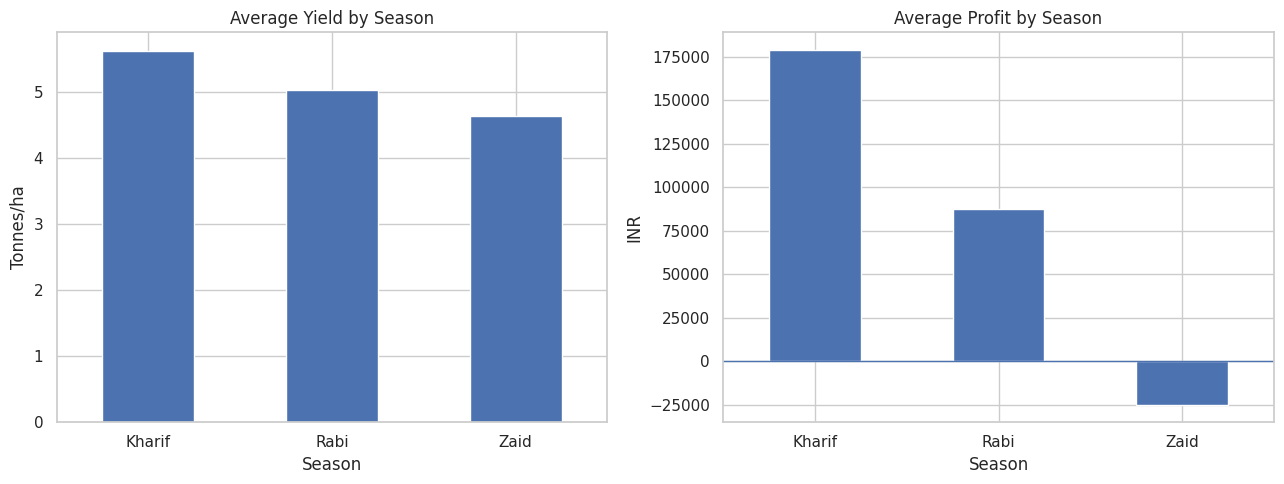

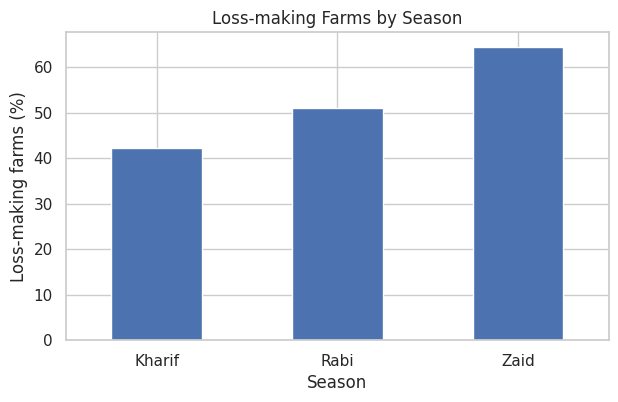

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

season_summary["Avg_Yield_t_ha"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Yield by Season")
axes[0].set_ylabel("Tonnes/ha")
axes[0].tick_params(axis="x", rotation=0)

season_summary["Avg_Profit_INR"].plot(kind="bar", ax=axes[1])
axes[1].axhline(0, linewidth=1)
axes[1].set_title("Average Profit by Season")
axes[1].set_ylabel("INR")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

loss_rate = clean.groupby("Season")["Profit_INR"].apply(lambda x: (x < 0).mean()*100)
loss_rate.plot(kind="bar", figsize=(7,4))
plt.title("Loss-making Farms by Season")
plt.ylabel("Loss-making farms (%)")
plt.xticks(rotation=0)
plt.show()

## 7. Environmental conditions by season

,Rainfall_mm,Temperature_C,Humidity_pct,Sunlight_hours,Soil_Moisture_pct,Disease_Risk_pct
Season,,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15,54.47
Rabi,437.62,23.49,57.89,7.59,24.07,40.48
Zaid,304.65,31.04,52.01,8.18,19.28,38.22


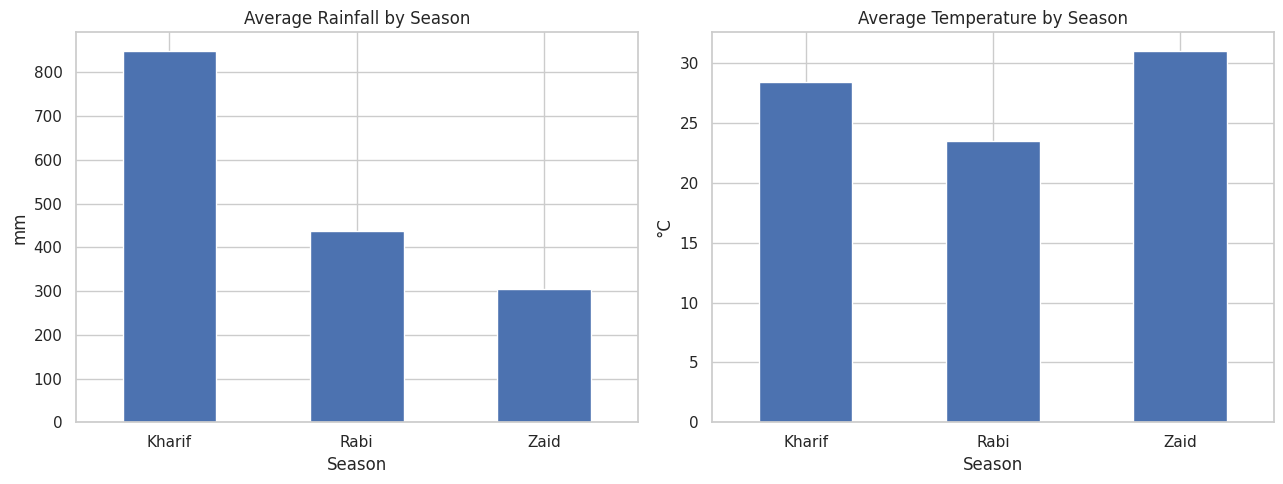

In [12]:
env = clean.groupby("Season").agg(
    Rainfall_mm=("Rainfall_mm","mean"),
    Temperature_C=("Avg_Temperature_C","mean"),
    Humidity_pct=("Humidity_pct","mean"),
    Sunlight_hours=("Sunlight_Hours_Day","mean"),
    Soil_Moisture_pct=("Soil_Moisture_pct","mean"),
    Disease_Risk_pct=("Disease_Pest_Risk_pct","mean")
).round(2)

display(env)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
env["Rainfall_mm"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Rainfall by Season")
axes[0].set_ylabel("mm")
axes[0].tick_params(axis="x", rotation=0)

env["Temperature_C"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Temperature by Season")
axes[1].set_ylabel("°C")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 8. Crop × season analysis



Farms  Avg_Yield_t_ha  Avg_Profit_INR  Avg_Water_Eff
Crop      Season                                                      
Chilli    Kharif    185            1.73       954380.42           3.26
          Rabi      163            1.47       638572.50           2.89
          Zaid       64            1.20       448659.09           2.20
Cotton    Kharif    215            1.37       216999.55           2.13
          Rabi      201            1.20       107343.59           1.94
          Zaid       92            0.96       -53925.34           1.49
Groundnut Kharif    193            1.48       108265.44           3.58
          Rabi      177            1.23        10416.54           2.90
          Zaid       54            1.04       -68872.50           2.47
Maize     Kharif    234            2.97       -39332.67           6.05
          Rabi      233            2.60       -89133.40           5.46
          Zaid       84            2.29      -194049.17           4.75
Pulses    Kharif    221            1.04        43338.90           3.35
          Rabi      213            0.88       -14309.14           2.70
          Zaid       62            0.67      -139227.81           1.95
Rice      Kharif    314            2.70       -64903.40           2.17
          Rabi      274            2.32       -98427.87           1.84
          Zaid      102            1.90      -227239.34           1.53
Sugarcane Kharif    125           53.46      1000790.81          36.00
          Rabi      129           43.29       731612.86          27.92
          Zaid       51           38.42       583635.80          23.39
Wheat     Kharif    292            2.25      -105871.87           4.76
          Rabi      237            2.06      -119954.57           4.69
          Zaid       85            1.75      -193208.95           4.02

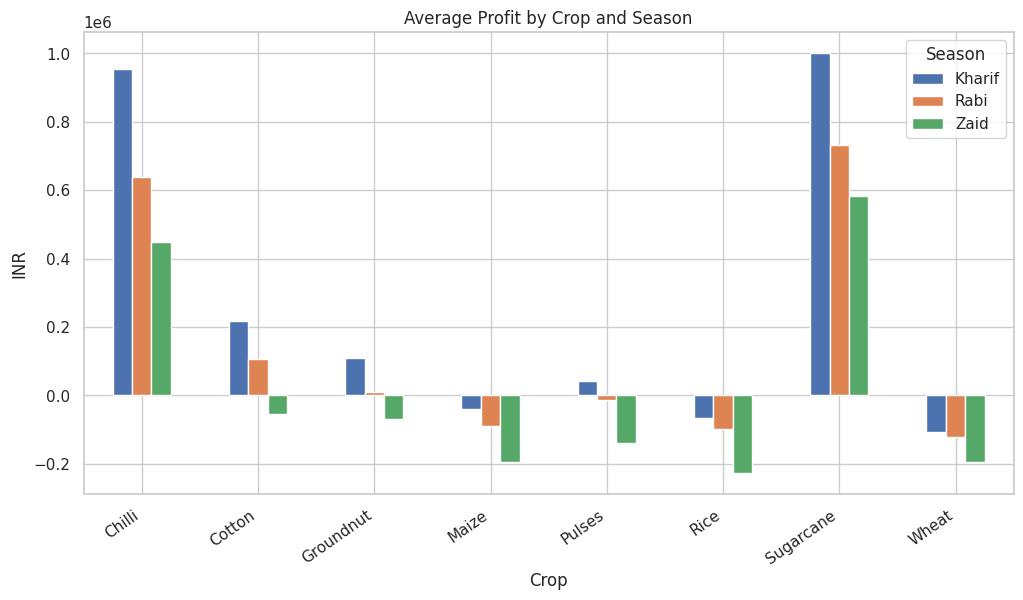

In [13]:
crop_season = clean.groupby(["Crop","Season"]).agg(
    Farms=("Farm_ID","count"),
    Avg_Yield_t_ha=("Yield_Tonnes_Ha","mean"),
    Avg_Profit_INR=("Profit_INR","mean"),
    Avg_Water_Eff=("Water_Efficiency_t_per_1000m3","mean")
).round(2)

display(crop_season)

profit_pivot = crop_season.reset_index().pivot(
    index="Crop", columns="Season", values="Avg_Profit_INR"
)
profit_pivot.plot(kind="bar", figsize=(12,6))
plt.title("Average Profit by Crop and Season")
plt.ylabel("INR")
plt.xticks(rotation=35, ha="right")
plt.show()

## 9. Irrigation method analysis

,Farms,Avg_Yield_t_ha,Avg_Profit_INR,Avg_Water_Eff,Loss_Rate_pct
Irrigation_Method,,,,,
Drip,915,6.58,219626.00,6.27,40.22
Sprinkler,734,5.16,91121.08,4.67,48.09
Rainfed,1041,4.60,79050.37,7.56,53.12
Flood,1310,4.86,73354.02,3.44,52.82


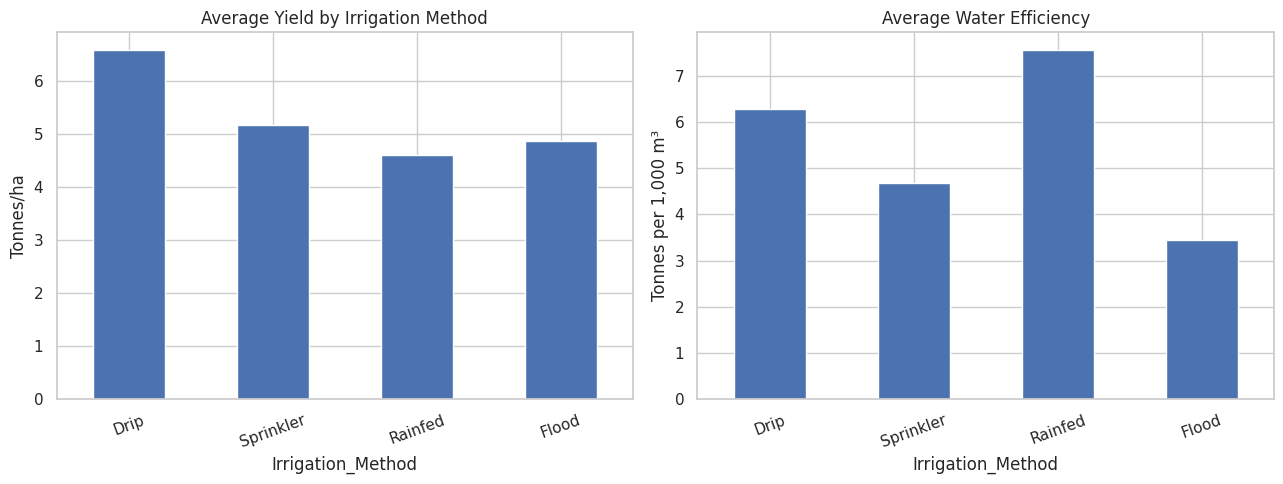

In [14]:
irrigation = clean.groupby("Irrigation_Method").agg(
    Farms=("Farm_ID","count"),
    Avg_Yield_t_ha=("Yield_Tonnes_Ha","mean"),
    Avg_Profit_INR=("Profit_INR","mean"),
    Avg_Water_Eff=("Water_Efficiency_t_per_1000m3","mean"),
    Loss_Rate_pct=("Profit_INR", lambda x: (x<0).mean()*100)
).sort_values("Avg_Profit_INR", ascending=False).round(2)

display(irrigation)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
irrigation["Avg_Yield_t_ha"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Yield by Irrigation Method")
axes[0].set_ylabel("Tonnes/ha")
axes[0].tick_params(axis="x", rotation=20)

irrigation["Avg_Water_Eff"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Water Efficiency")
axes[1].set_ylabel("Tonnes per 1,000 m³")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 10. Relationships between variables



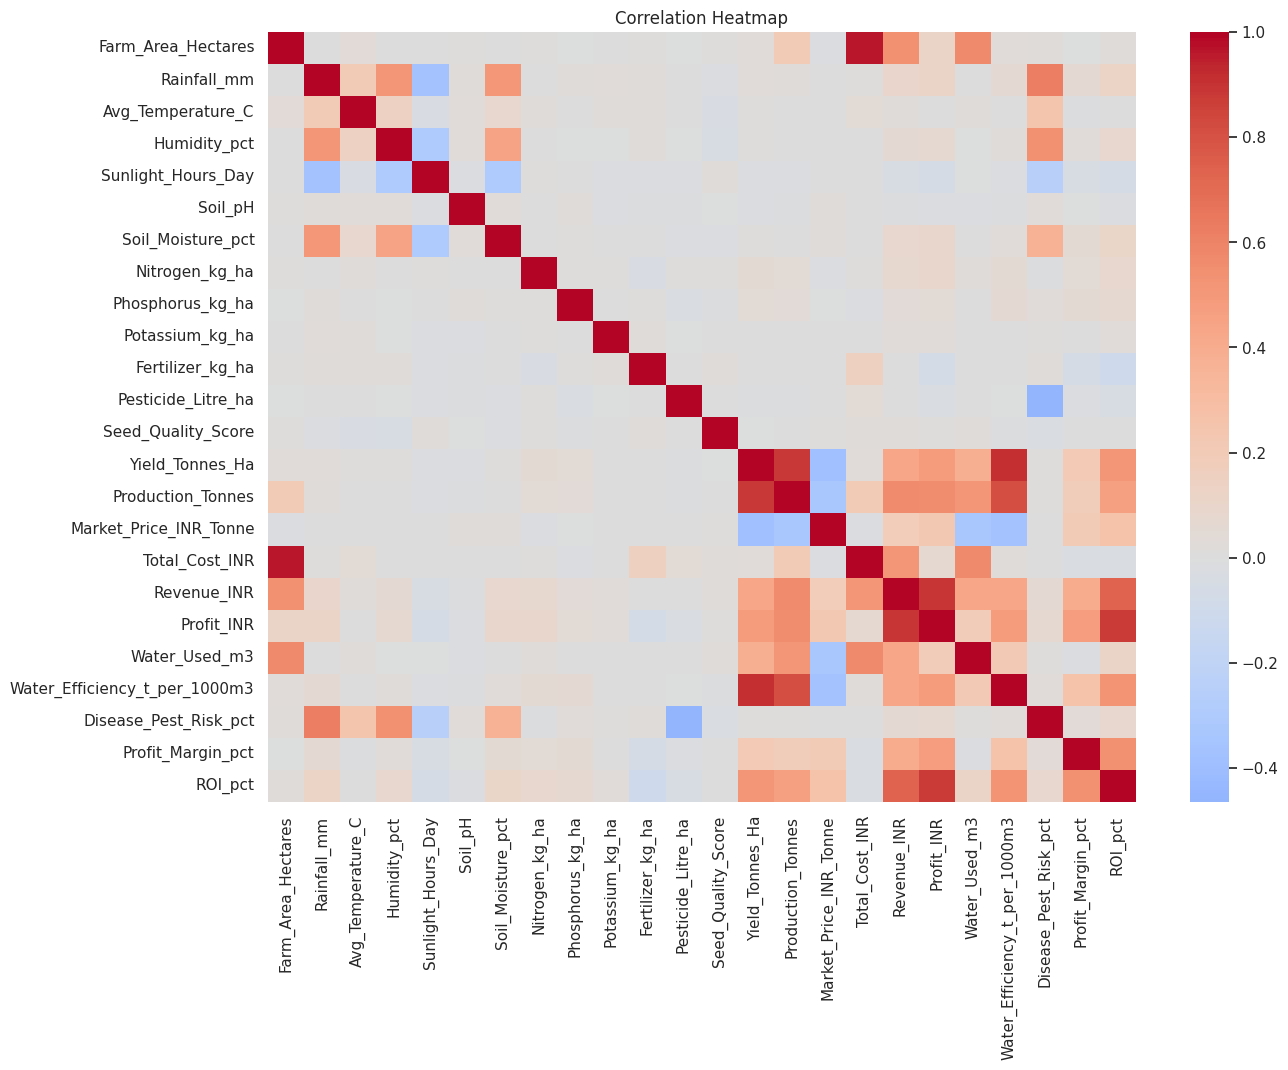

Top correlations with Yield:


,correlation
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
ROI_pct,0.524170
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Profit_Margin_pct,0.204993
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941


Top correlations with Profit:


,correlation
Profit_INR,1.000000
Revenue_INR,0.887331
ROI_pct,0.878580
Production_Tonnes,0.554172
Water_Efficiency_t_per_1000m3,0.489487
Yield_Tonnes_Ha,0.488466
Profit_Margin_pct,0.481375
Market_Price_INR_Tonne,0.225119
Water_Used_m3,0.190278
Farm_Area_Hectares,0.115241


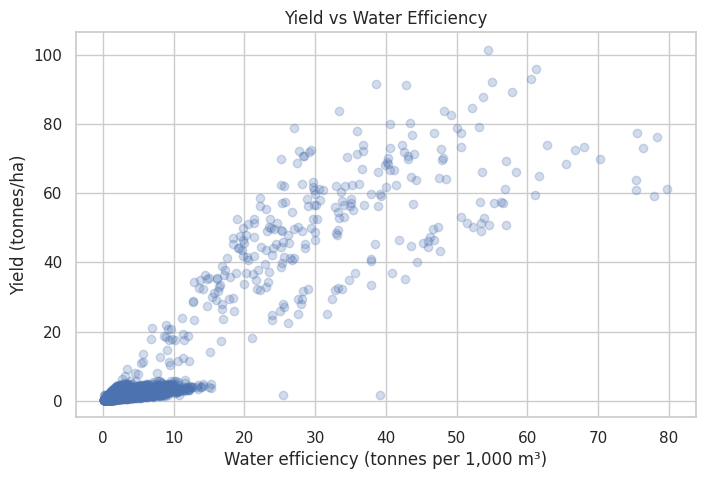

In [15]:
numeric_cols = clean.select_dtypes(include=np.number).columns
corr = clean[numeric_cols].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

yield_corr = corr["Yield_Tonnes_Ha"].sort_values(ascending=False)
profit_corr = corr["Profit_INR"].sort_values(ascending=False)

print("Top correlations with Yield:")
display(yield_corr.head(10).to_frame("correlation"))

print("Top correlations with Profit:")
display(profit_corr.head(10).to_frame("correlation"))

plt.figure(figsize=(8,5))
plt.scatter(clean["Water_Efficiency_t_per_1000m3"],
            clean["Yield_Tonnes_Ha"], alpha=0.25)
plt.xlabel("Water efficiency (tonnes per 1,000 m³)")
plt.ylabel("Yield (tonnes/ha)")
plt.title("Yield vs Water Efficiency")
plt.show()

## 11. Statistical testing



In [ ]:
seasons = clean["Season"].unique()

yield_groups = [
    clean.loc[clean["Season"]==s, "Yield_Tonnes_Ha"]
    for s in seasons]
profit_groups = [
    clean.loc[clean["Season"]==s, "Profit_INR"]
    for s in seasons]
water_groups = [
    clean.loc[clean["Season"]==s, "Water_Efficiency_t_per_1000m3"]
    for s in seasons]

kw_yield = stats.kruskal(*yield_groups)
anova_profit = stats.f_oneway(*profit_groups)
anova_water = stats.f_oneway(*water_groups)

print("Kruskal-Wallis — Yield:", kw_yield)
print("One-way ANOVA — Profit:", anova_profit)
print("One-way ANOVA — Water efficiency:", anova_water)

print("\nPairwise Mann-Whitney tests for yield:")
for a, b in [("Kharif","Rabi"),("Kharif","Zaid"),("Rabi","Zaid")]:
    result = stats.mannwhitneyu(
        clean.loc[clean["Season"]==a,"Yield_Tonnes_Ha"],
        clean.loc[clean["Season"]==b,"Yield_Tonnes_Ha"],
        alternative="two-sided"
    )
    print(f"{a} vs {b}: p = {result.pvalue:.6g}")

## 12. Outlier investigation



In [ ]:
print("Yield observations above 20 tonnes/ha:",
      (clean["Yield_Tonnes_Ha"] > 20).sum())

display(
    clean.loc[clean["Yield_Tonnes_Ha"] > 20,
              ["Farm_ID","Crop","Season","Yield_Tonnes_Ha",
               "Production_Tonnes","Farm_Area_Hectares"]]
    .sort_values("Yield_Tonnes_Ha", ascending=False)
    .head(15)
)

print("\nAverage yield by crop:")
display(clean.groupby("Crop")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False).round(2))

## 13. Key findings

Expected conclusions from this dataset:

- **Kharif** has the strongest overall seasonal performance: highest average yield and highest average profit.
- **Zaid** has the weakest economics: average profit is negative and its loss-making share is the highest.
- Kharif also has the highest average rainfall, while Zaid has the lowest rainfall and highest average temperature.
- **Drip irrigation** has the highest average yield and highest average profit among the irrigation methods in this dataset.
- Yield is strongly associated with water-efficiency in the raw dataset, but this relationship should not be interpreted as causal because water efficiency is mathematically linked to production/yield.
- Profit differs substantially by crop. Sugarcane and Chilli show high average profits, while Wheat, Rice and Maize show negative average profits in the supplied data.
- Seasonal analysis should be interpreted together with crop mix, irrigation method and environmental conditions.